# Paper visualizations

This notebook was used to produce the visualizations for the paper, starting from the generation traces. The state of the notebook is still a draft, but in the future I will clean it up and make it more presentable. For now, it serves as a record of the process I used to create the figures for the paper.

In [1]:
models = ['1-3', '1-2-8']
seeds = [0, 1, 2]

In [2]:
import torch
chains = {}

for model in models:
    if model not in chains:
        chains[model] = {}
    for seed in seeds:
        path = f'chains/enz_{seed}_{model}.pt'
        chains[model][seed] = torch.load(path, map_location='cpu')

/var/folders/th/9ytylx9n7q786kxws3tb4w4c0000gn/T/ipykernel_62373/1467028503.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chains[model][seed] = torch.load(path, map_lo

In [3]:
max_y = 0.09
path = 'chains/plots/'

In [23]:
# change font size of matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 15})

In [132]:
model = '1-3'
seed = 0

chains[model][seed][0][0].keys()

dict_keys(['time', 'graph', 'remaining_graphs_idx', 'nodes_inserted', 'pred_insert', 'halt_signal', 'pred_halt'])

In [133]:
chains[model][seed][0][1]['nodes_inserted']

tensor([3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3], dtype=torch.int32)

In [136]:
chains[model][seed][0][0]['graph']

SparseGraphBatch(x=[0, 1], edge_index=[2, 0], edge_attr=[0, 1], batch=[0], ptr=[113], y=[112, 16])

In [5]:
import torch

chain = chains[model][1][0]
num_graphs = chain[0]['graph'].num_graphs

def get_num_nodes_trajectories(chain):
    
    curr_num_nodes = chain[0]['graph'].num_nodes_per_sample
    num_nodes = []

    for sample in chain:
        new_num_nodes = curr_num_nodes.clone()
        new_num_nodes[sample['remaining_graphs_idx']] = sample['graph'].num_nodes_per_sample
        num_nodes.append(new_num_nodes)
        curr_num_nodes = new_num_nodes
    return num_nodes

def get_halting_prob_trajectories(chain):
    
    num_graphs = chain[0]['graph'].num_graphs
    halting_probs = []

    for sample in chain[1:]:
        new_halting_probs = torch.ones(num_graphs, dtype=torch.float)
        new_halting_probs[sample['remaining_graphs_idx']] = torch.sigmoid(sample['pred_halt'])
        halting_probs.append(new_halting_probs)
    return halting_probs

def get_blocks_trajectories(chain):
    
    num_graphs = chain[0]['graph'].num_graphs
    blocks = []

    for sample in chain[1:]:
        new_blocks = torch.zeros(num_graphs, dtype=torch.int32)
        new_blocks[sample['remaining_graphs_idx']] = sample['nodes_inserted']
        blocks.append(new_blocks)
    return blocks

def get_graphs_trajectories(chain):
    graphs = []
    current_graphs = [None] * num_graphs
    for sample in chain:
        for i, j in enumerate(sample['remaining_graphs_idx']):
            current_graphs[j] = sample['graph'][i]
        graphs.append(current_graphs)
    return graphs, current_graphs

In [6]:
def cat_and_pad(tensors, pad_value=None):
    # pad each tensor with the last column
    max_len = max(tensor.shape[1] for tensor in tensors)
    padded_tensors = []
    for tensor in tensors:
        pad_size = max_len - tensor.shape[1]
        if pad_size > 0:
            if pad_value is None:
                pad = tensor[:, -1].unsqueeze(1).repeat(1, pad_size)
            else:
                pad = torch.full((tensor.shape[0], pad_size), pad_value, dtype=tensor.dtype)
            padded_tensor = torch.cat([tensor, pad], dim=1)
        else:
            padded_tensor = tensor
        padded_tensors.append(padded_tensor)
    return torch.cat(padded_tensors, dim=0)

In [7]:
from torch_geometric.data import Batch

def get_num_nodes_and_halt_prob(chains, model):
    
    num_nodes = []
    halt_prob = []
    blocks = []
    graphs = []
    for seed in seeds:
        num_nodes.append(torch.stack(get_num_nodes_trajectories(chains[model][seed][0]), dim=1))
        halt_prob.append(torch.stack(get_halting_prob_trajectories(chains[model][seed][0]), dim=1))
        blocks.append(torch.stack(get_blocks_trajectories(chains[model][seed][0]), dim=1))
        graphs.extend(get_graphs_trajectories(chains[model][seed][0])[1])
    
    num_nodes_tens = cat_and_pad(num_nodes)
    halt_prob_tens = cat_and_pad(halt_prob, pad_value=1.0)
    blocks_tens = cat_and_pad(blocks, pad_value=0)
    last_graphs = Batch.from_data_list(graphs)

    prod_halt = torch.ones((halt_prob_tens.shape[0], halt_prob_tens.shape[1]+1), dtype=torch.float)
    prod_halt[:, 2:] = (1-halt_prob_tens).cumprod(dim=1)[:, :-1]
    prior_halt = torch.zeros_like(prod_halt)
    prior_halt[:, 1:] = halt_prob_tens * prod_halt[:, 1:]
    
    return num_nodes_tens, prior_halt, blocks_tens, last_graphs

In [8]:
def prob_to_hist(probs, num_nodes, max_num_nodes):
    hist = torch.zeros(max_num_nodes + 1, dtype=torch.float)
    hist.scatter_reduce_(0, num_nodes.flatten(), probs.flatten(), reduce='sum', include_self=False)
    hist /= probs.shape[0]
    return hist

In [9]:
from torch.nn.functional import one_hot

def get_all_hists(chains, model, range_data):
    num_nodes_tens, prior_halt, blocks_tens, last_graphs = get_num_nodes_and_halt_prob(chains, model)
    
    final_num_nodes = num_nodes_tens[:,-1]
    gen_num_nodes, gen_hist = final_num_nodes.unique(return_counts=True)
    
    blocks, inv_map = blocks_tens.unique(return_inverse=True)
    
    blocks_onehot = one_hot(inv_map, num_classes=blocks.shape[0])
    blocks_hist = blocks_onehot.mean(dim=0, dtype=torch.float)
    
    max_num_nodes = num_nodes_tens.max().item()
    max_time = num_nodes_tens.shape[1]
    avg_tensor = torch.zeros((max_num_nodes + 1, max_time), dtype=torch.float)
    for n in range(max_num_nodes + 1):
        which_ones = final_num_nodes == n
        how_many = which_ones.sum().item()
        how_many = max(how_many, 1)
        for t in range(max_time):
            num_nodes_n_t = num_nodes_tens[which_ones, t]
            which_ones_no_constant = which_ones & (num_nodes_tens[:, t] != final_num_nodes)
            how_many = which_ones_no_constant.sum().item()
            how_many = max(how_many, 1)
            avg_tensor[n, t] = num_nodes_tens[which_ones_no_constant, t].sum(dtype=torch.float).item() / how_many
    
    gen_hist_partial = gen_hist / num_nodes_tens.shape[0]
    gen_hist = torch.zeros(range_data[1]+1)
    gen_hist[gen_num_nodes] = gen_hist_partial
    
    prob_hist = prob_to_hist(prior_halt, num_nodes_tens, range_data[1])
    
    return num_nodes_tens, gen_hist, prob_hist, prior_halt, avg_tensor, blocks, blocks_hist, blocks_tens, last_graphs

In [126]:
model = '1-3'
num_nodes_tens, gen_hist, prob_hist, prior_halt, avg_tensor, blocks, blocks_hist, blocks_tens, last_graphs = get_all_hists(chains, model, (0, 123))

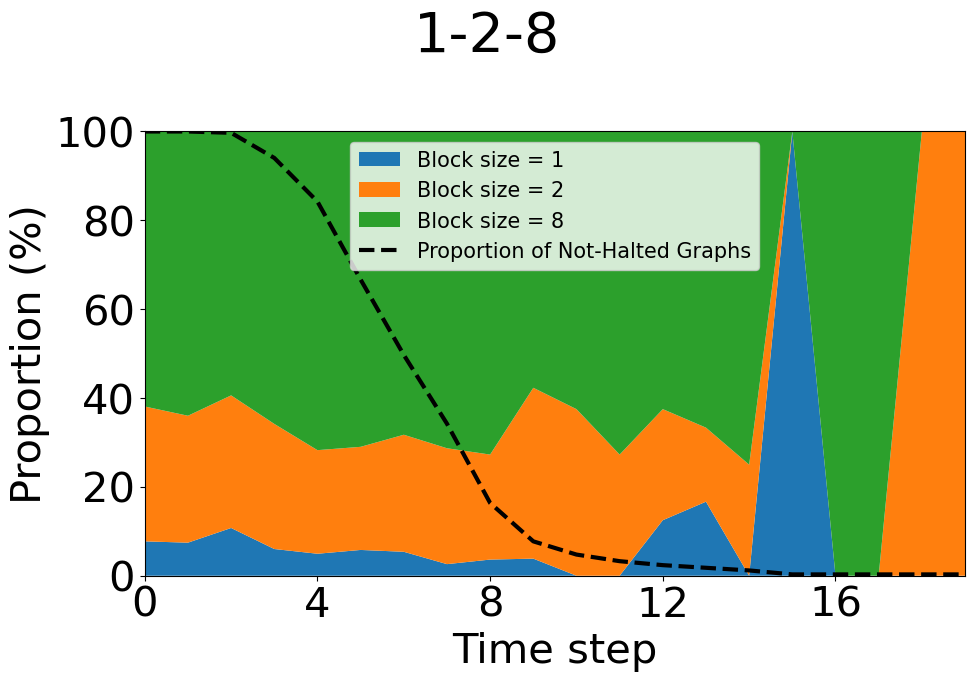

In [115]:
# plot areas of blocks_hist, overlapping
# x axis has timestep, use a different color per timestep, each area is high proportional to the histogram value, stacked
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(10, 6))

hist = blocks_hist.T.numpy()[1:]
frac_alive_graphs = hist.sum(axis=0)

plt.stackplot(
    range(blocks_hist.shape[0]),
    hist / hist.sum(axis=0, keepdims=True) * 100,
    labels=[f'Block size = {b}' for b in blocks[1:]]
)
plt.plot(range(blocks_hist.shape[0]), frac_alive_graphs * 100, label='Proportion of Not-Halted Graphs', color='black', linestyle='--', linewidth=3)

col_titles = models

# pos = plt.get_position()            # Bbox in figure coords
# cx = 0.5 * (pos.x0 + pos.x1)           # center x
# place slightly above the top of the axes
fig.text(0.5, 1.05, model, ha='center', va='bottom', fontsize=40)

# change font of ticks and labels
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

plt.xlabel('Time step', fontdict={'fontsize': 30})
plt.ylabel('Proportion (%)', fontdict={'fontsize': 30})
#plt.title('Proportion of Sampled Block Sizes over Time')
plt.legend(loc='upper center')
# white spaces
plt.ylim(0, 100)
plt.xlim(0, blocks_hist.shape[0]-1)
plt.xticks(np.arange(0, blocks_hist.shape[0], 4))
plt.tight_layout()
fig.savefig(f'{path}/blocks_{model}.pdf', bbox_inches='tight')
plt.show()

In [127]:
idx = torch.arange(blocks_tens.shape[1]).unsqueeze(0).repeat(blocks_tens.shape[0], 1).flatten()
orders = torch.repeat_interleave(idx, repeats=blocks_tens.flatten(), dim=0)

edge_index_maxed = last_graphs.edge_index.max(0)[0]
edge_orders = orders[edge_index_maxed]

print(edge_orders)

tensor([0, 0, 1,  ..., 9, 9, 9])


In [128]:
from copy import deepcopy

last_graphs.node_orders = orders
last_graphs._slice_dict['node_orders'] = deepcopy(last_graphs._slice_dict['x'])
last_graphs._inc_dict['node_orders'] = last_graphs._inc_dict['x']

last_graphs.edge_orders = edge_orders
last_graphs._slice_dict['edge_orders'] = deepcopy(last_graphs._slice_dict['edge_attr'])
last_graphs._inc_dict['edge_orders'] = last_graphs._inc_dict['edge_attr']

In [129]:
import networkx as nx
import matplotlib.pyplot as plt

def display_graphs(nx_graphs, ds_model, cmap=plt.cm.viridis, rows=1, cols=5, width=4, barwidth=1., node_size=50, save=False):
    orientation = 'vertical' if cols > rows else 'horizontal'
    ver_barwidth = barwidth if orientation == 'vertical' else 0
    hor_barwidth = barwidth if orientation == 'horizontal' else 0
    
    fig, axs_orig = plt.subplots(rows, cols, figsize=(width * cols + ver_barwidth, width * rows + hor_barwidth))
    axs = axs_orig.flatten() if isinstance(axs_orig, np.ndarray) else [axs_orig]
    for i in range(rows * cols):
        g = nx_graphs[i]
        pos = nx.spring_layout(g)
        color = [n[1]['node_orders'] for n in g.nodes(data=True)]
        edge_colors = [e[2]['edge_orders'] for e in g.edges(data=True)]
        # sample cmaps with values from 0 to max of node_orders
        max_time = max(color) if color else 1
        node_cmap = plt.cm.viridis.resampled(max_time + 1).colors
        edge_cmap = node_cmap
        node_colors = node_cmap[color]
        edge_colors = edge_cmap[edge_colors]
        # map color to a colormap
        #color = plt.cm.viridis(color / max(color))
        nx.draw(g, pos=pos, node_size=node_size, ax=axs[i], node_color=node_colors, edge_color=edge_colors)
    
    # use scale from 0% to 100%
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=axs_orig, orientation=orientation, label='Order of Insertion (%)')
    cbar.set_ticklabels([str(i) for i in [0, 20, 40, 60, 80, 100]])
    # move bar up if horizontal
    if orientation == 'horizontal':
        cbar.ax.set_position([0.1, 0.28, 0.8, 0.03])

    if save:
        fig.savefig(f'{path}/evol_{ds_model}.pdf', bbox_inches='tight')

In [ ]:
from src.data.simple_transforms.graph import graph2nx

graphs_list = last_graphs.to_data_list()
batch_size = len(graphs_list) / 3

graphs_per_seed = [[graphs_list[i] for i in range(int(j * batch_size), int((j + 1) * batch_size))] for j in range(3)]

last_graphs_nx = [graph2nx(graphs_per_seed[seed], to_undirected=True, node_attrs=['node_orders'], edge_attrs=['edge_orders']) for seed in range(3)]

/var/folders/th/9ytylx9n7q786kxws3tb4w4c0000gn/T/ipykernel_62373/4023089903.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels([str(i) for i in [0, 20, 40, 60, 80, 100]])


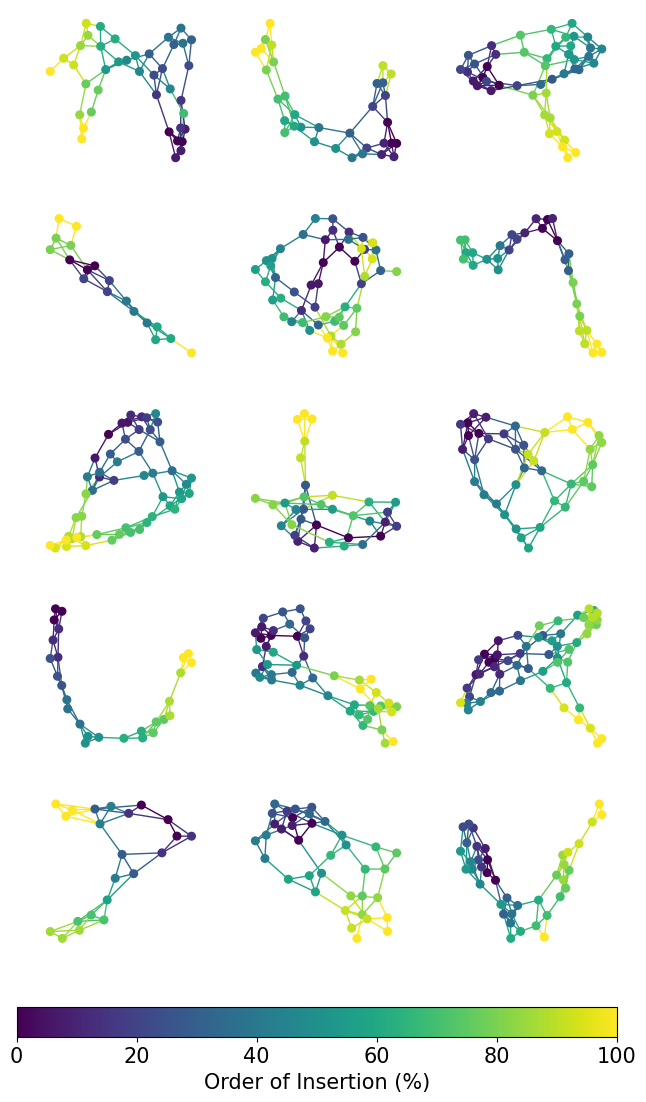

In [141]:
display_graphs(last_graphs_nx[0], model, rows=5, cols=3, width=2.5, node_size=30, save=True, cmap=plt.cm.viridis, barwidth=5)

In [165]:
matrix = get_all_hists(chains, '1-2-8', (0, 123))[-1]
deriv_matrix = matrix[:, 1:] - matrix[:, :-1]
deriv_matrix[deriv_matrix < 0] = 0

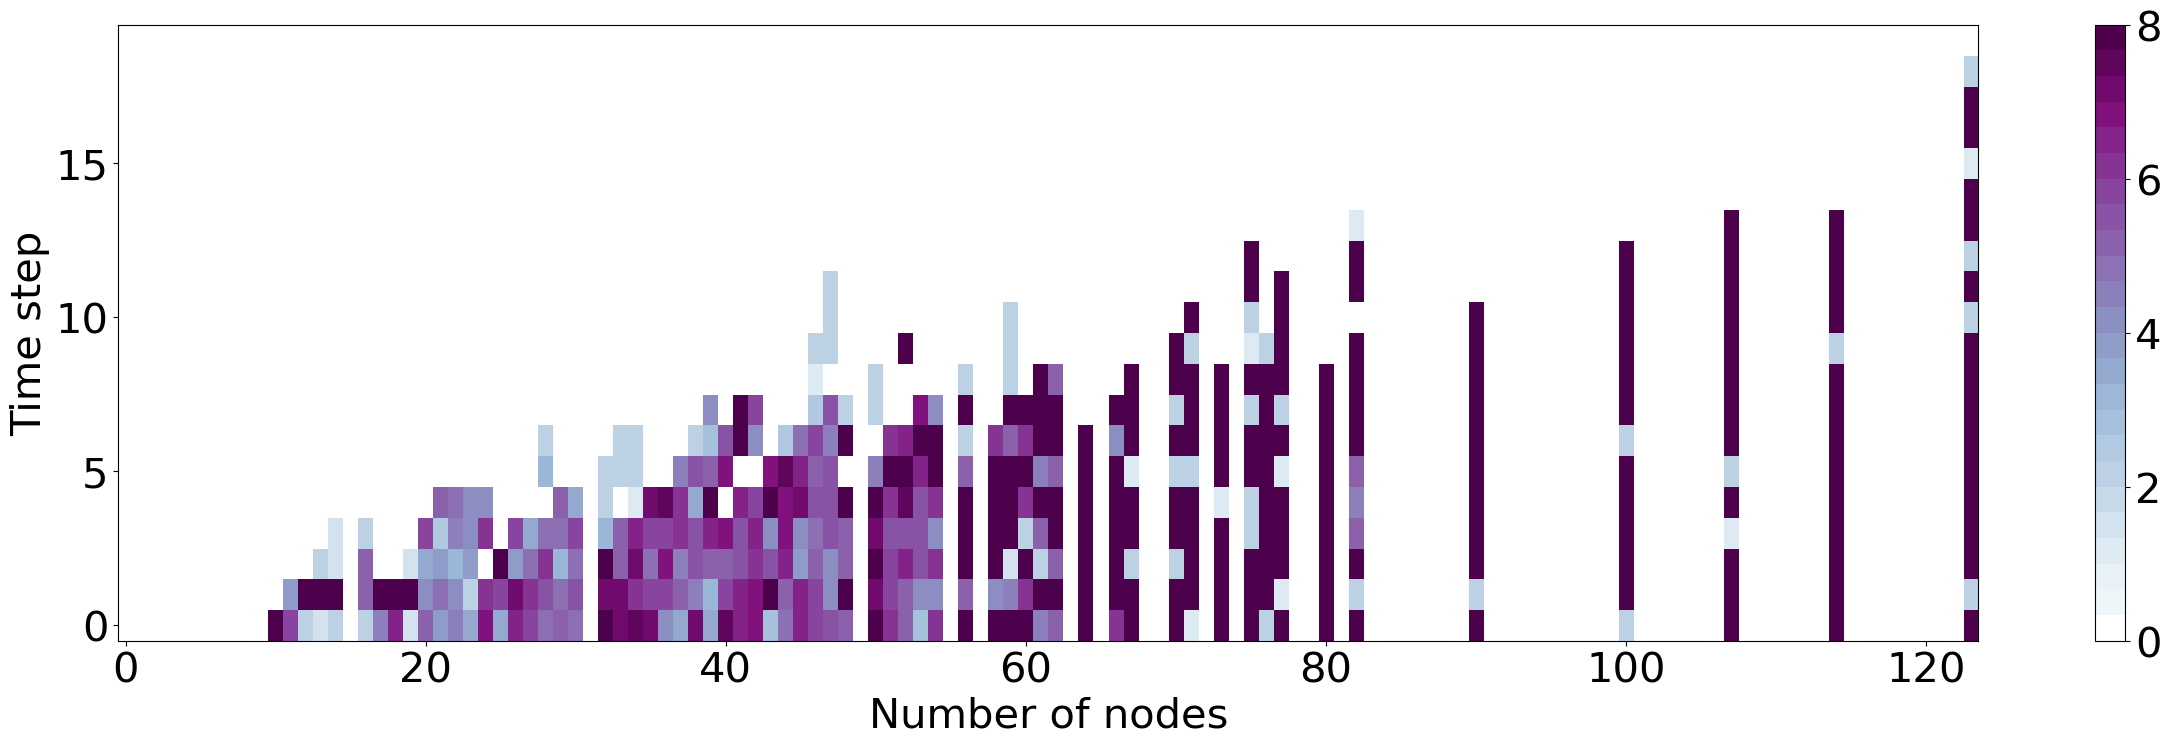

In [132]:
# plot matrix as a heatmap
# substitute 0 values in the colormap with white
import numpy as np
import matplotlib as mpl
how_many_colors = 3
cmap = plt.cm.BuPu.resampled(deriv_matrix.max().item() * how_many_colors)
cmap = cmap(np.arange(cmap.N))
cmap[0, :3] = 1.0
cmap = mpl.colors.ListedColormap(cmap)

plt.figure(figsize=(30, 8))
plt.imshow(deriv_matrix.transpose(0,1), aspect='auto', origin='lower', cmap=cmap)
plt.colorbar()
plt.ylabel('Time step')
plt.xlabel('Number of nodes')
plt.show()

### Manual plotting

In [569]:
range_data = (0, 123)
num_nodes_tens, gen_hist, prob_hist = get_all_hists(chains, model, range_data)

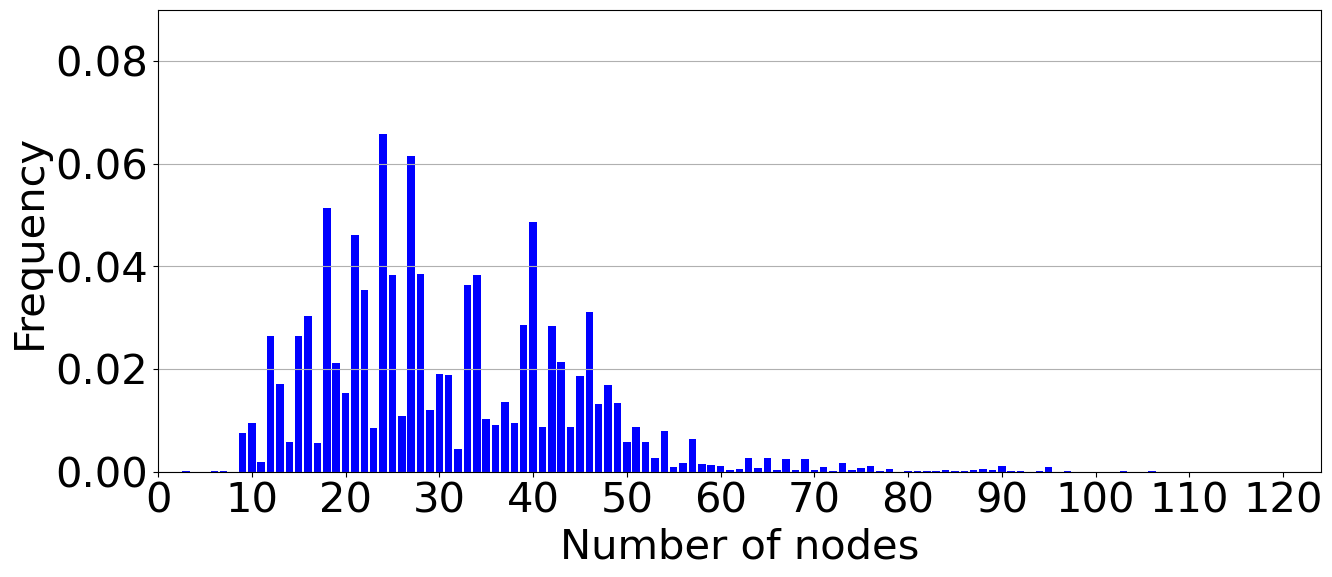

In [570]:
# plot data_hist
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(15, 6))
plt.bar(range(range_data[1] + 1), prob_hist, color='blue')
plt.xlabel('Number of nodes')
plt.ylabel('Frequency')
#splt.title('Distribution of number of nodes in Enzymes dataset')
plt.xlim(0, range_data[1] + 1)
plt.ylim(0, max_y)
# change number of x ticks
plt.xticks(range(0, range_data[1] + 1, 10))
# save as pdf
plt.grid(axis='y')
fig.savefig(f'{path}prob_{model}.pdf', bbox_inches='tight')
plt.show()

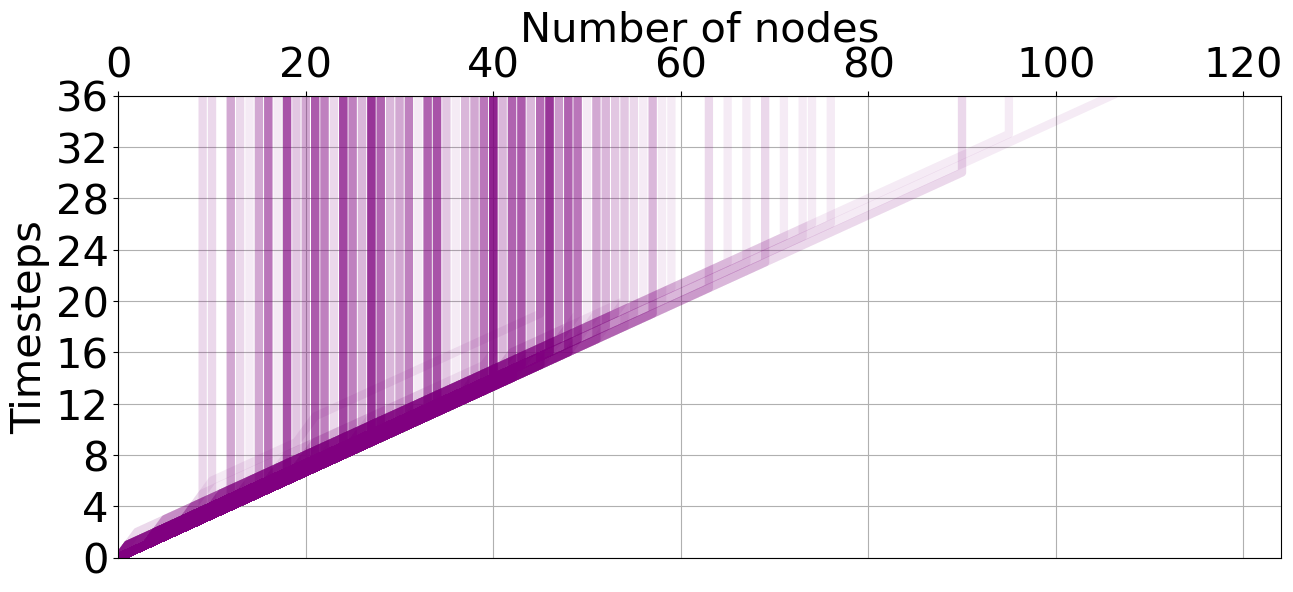

In [571]:
# plot trajectories
# x axis is step, y axis is num nodes
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(15, 6))
for i in range(num_nodes_tens.shape[0]):
    plt.plot(num_nodes_tens[i], np.arange(num_nodes_tens.shape[-1]), label=f'Graph {i}', color='purple', alpha=0.08, linewidth=6)
plt.ylabel('Timesteps')
plt.xlabel('Number of nodes')
# put ticks and ylabel on the right axis
plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position("top")
plt.ylim(0, num_nodes_tens.shape[-1]-1)
plt.xlim(0, range_data[1] + 1)
# use only integer ticks on y axis
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.grid()
fig.savefig(f'{path}traj_{model}.pdf', bbox_inches='tight')
plt.show()

In [572]:
gen_num_nodes, gen_hist = num_nodes_tens[:,-1].unique(return_counts=True)
gen_hist_partial = gen_hist / num_nodes_tens.shape[0]
gen_hist = torch.zeros(range_data[1]+1)
gen_hist[gen_num_nodes] = gen_hist_partial

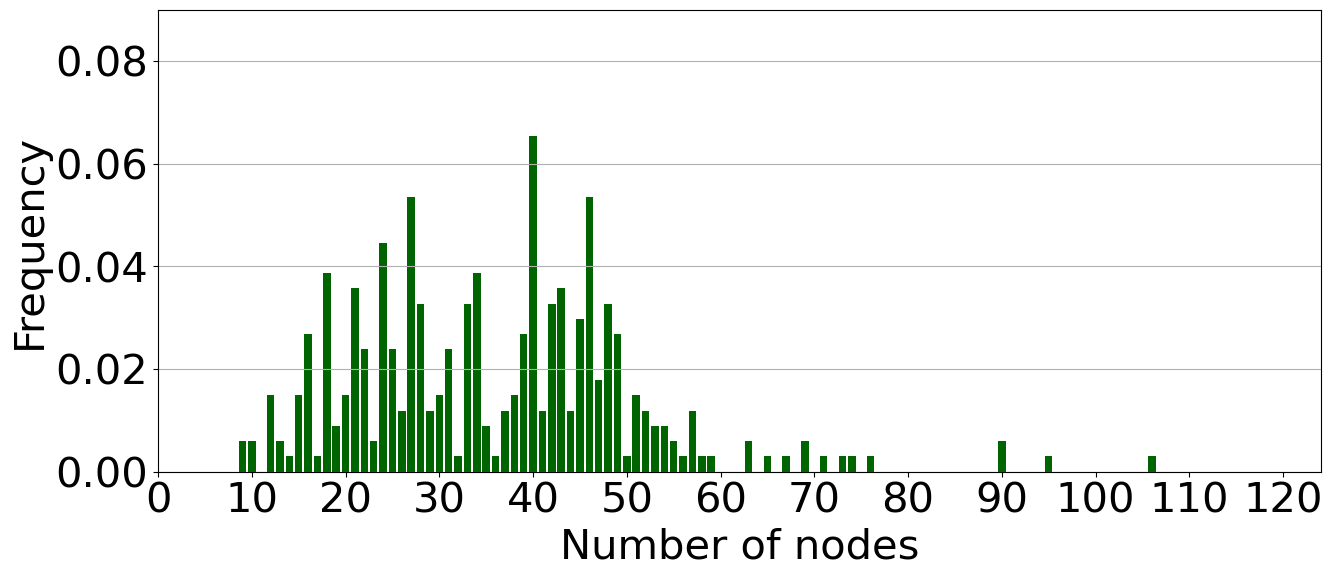

In [573]:
# plot data_hist
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(15, 6))
plt.bar(range(range_data[1] + 1), gen_hist, color='darkgreen')
plt.xlabel('Number of nodes')
plt.ylabel('Frequency')
#plt.title('Distribution of number of nodes in Enzymes dataset')
plt.xlim(0, range_data[1] + 1)
plt.ylim(0, max_y)
# change number of x ticks
plt.xticks(range(0, range_data[1] + 1, 10))
plt.grid(axis='y')
fig.savefig(f'{path}gen_{model}.pdf', bbox_inches='tight')
plt.show()

In [574]:
gen_hist.max()

tensor(0.0655)

## Dataset

In [ ]:
from src.data.datasets.graphgdp_datasets import Enzymes

ds_enz_train = Enzymes(split="train")

In [12]:
import numpy as np
data_hist = ds_enz_train.stats['num_nodes_hist']
data_hist = {int(k): v/len(ds_enz_train) for k, v in data_hist.items()}
range_data = (min(data_hist.keys()), max(data_hist.keys()))
data_hist_np = np.zeros(range_data[1]+1)
data_hist_np[np.array(list(data_hist.keys()))] = list(data_hist.values())

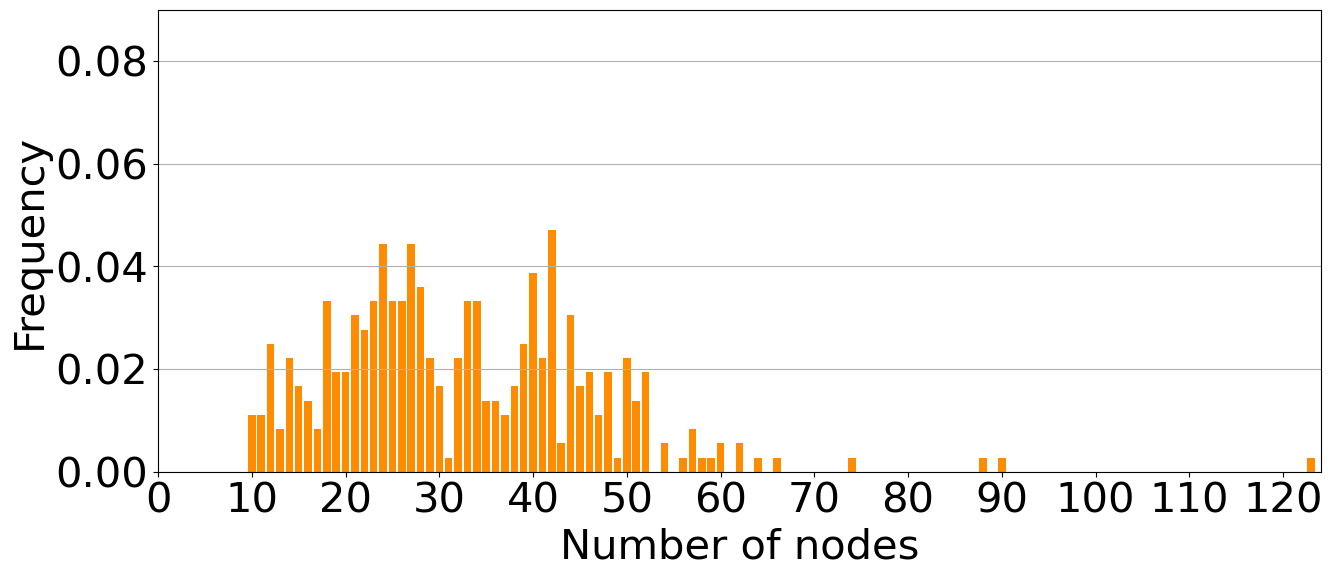

In [577]:
# plot data_hist
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(15, 6))
plt.bar(range(range_data[1] + 1), data_hist_np, color='darkorange')
plt.xlabel('Number of nodes')
plt.ylabel('Frequency')
#plt.title('Distribution of number of nodes in Enzymes dataset')
plt.xlim(0, range_data[1] + 1)
plt.ylim(0, max_y)
plt.xticks(range(0, range_data[1] + 1, 10))
plt.grid(axis='y')
fig.savefig(f'{path}data_{model}.pdf', bbox_inches='tight')
plt.show()

# putting everything together

In [17]:
def plot_hist(hist, range_data, ax, color, title=None, have_xlabel=True, have_ylabel=True):
    ax.bar(np.arange(range_data[1] + 1), hist[:range_data[1]+1], color=color)
    if have_xlabel:
        ax.set_xlabel('Number of nodes')
    if have_ylabel:
        ax.set_ylabel('Frequency')
    ax.set_xlim(0, 125)
    ax.set_ylim(0, max_y)
    ax.grid(axis='y')
    if title:
        ax.set_title(title)
    
def plot_traj(num_nodes_tens, range_data, ax, color, have_xlabel=True, have_ylabel=True):
    for i in range(num_nodes_tens.shape[0]):
        ax.plot(num_nodes_tens[i], np.arange(num_nodes_tens.shape[-1]), label=f'Graph {i}', color=color, alpha=0.08, linewidth=6)
    if have_ylabel:
        ax.set_ylabel('Timesteps')
    if have_xlabel:
        ax.set_xlabel('Number of nodes')
    # put ticks and ylabel on the right axis
    ax.xaxis.tick_top()
    #ax.xaxis.set_label_position("top")
    ax.set_ylim(0, num_nodes_tens.shape[-1]-1)
    ax.set_xlim(0, 125)
    # use only integer ticks on y axis
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=5))
    ax.grid()

/var/folders/th/9ytylx9n7q786kxws3tb4w4c0000gn/T/ipykernel_3135/2281127429.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


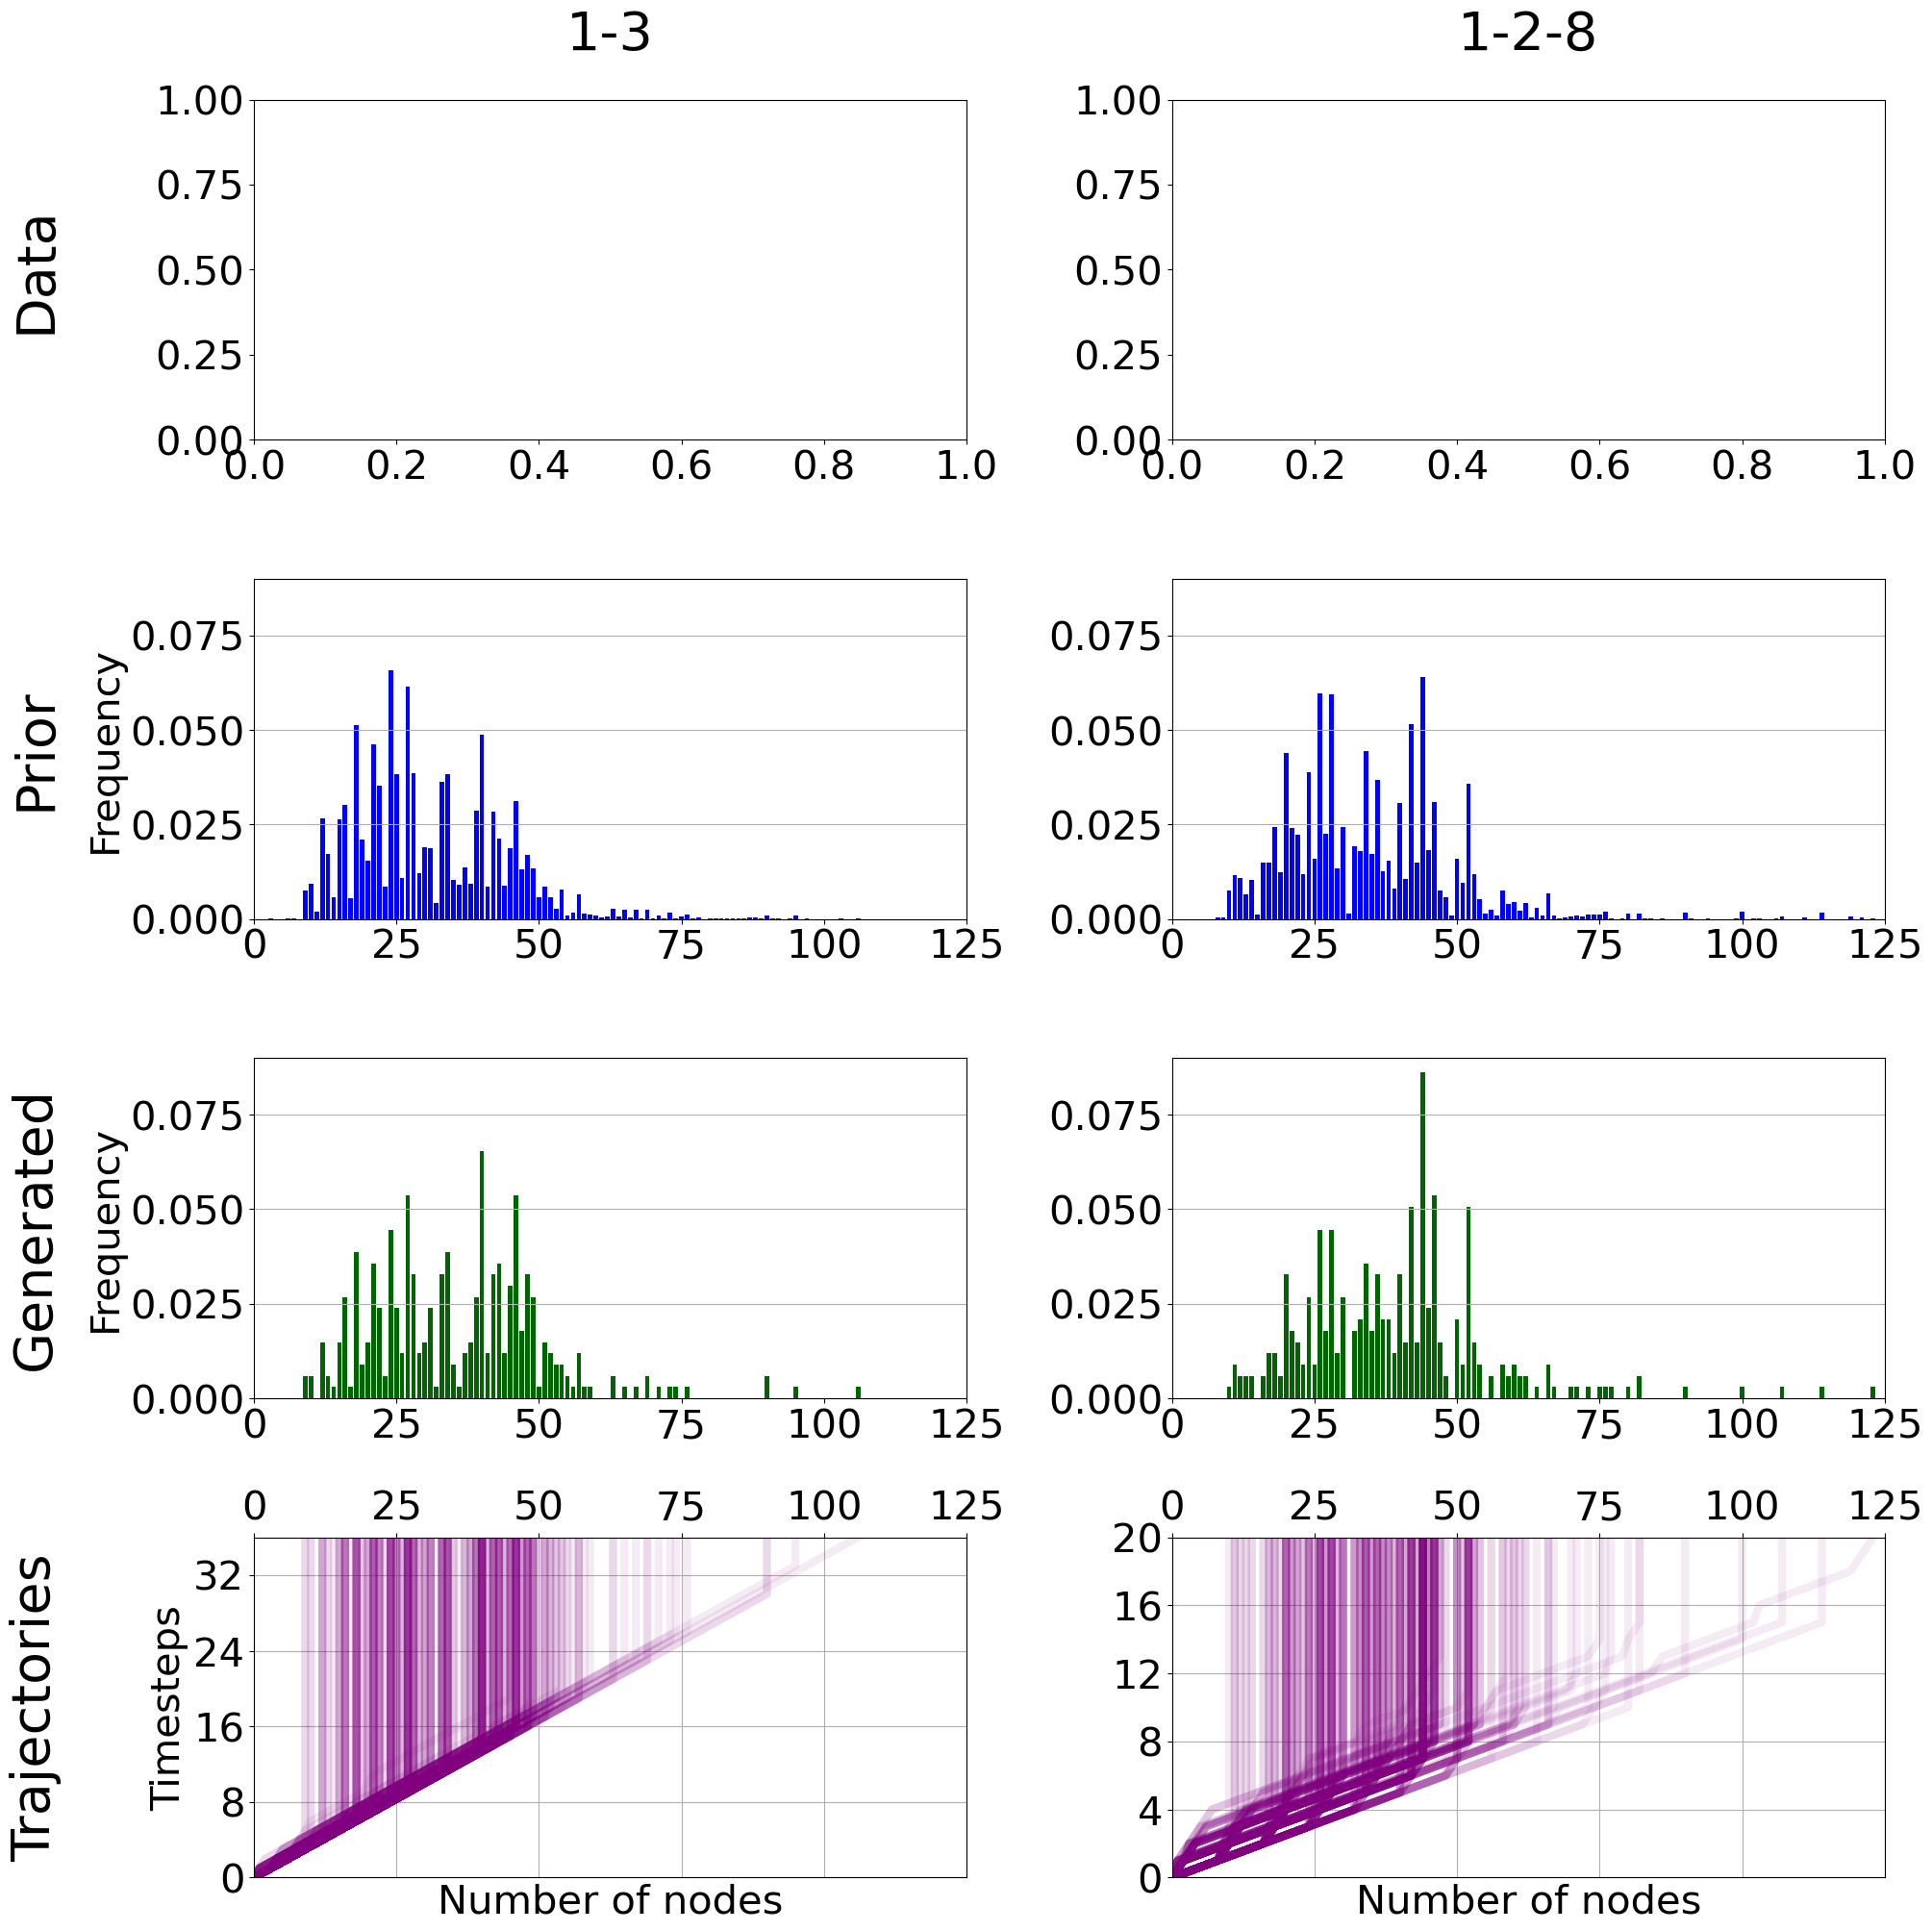

In [21]:
# create mega plot with 8 subplots, 2 columns and 4 rows, but do not show it yet
import matplotlib.pyplot as plt
import numpy as np

ncols = 2
nrows = 4

fig, axs = plt.subplots(nrows, ncols, figsize=(20, 20))

row_titles = ['Data', 'Prior', 'Generated', 'Trajectories']

axs = axs.T

range_data = (0, 123)

for i, (model, ax_col) in enumerate(zip(models, axs)):
    num_nodes_tens, gen_hist, prob_hist = get_all_hists(chains, model, range_data)
    
    #plot_hist(data_hist_np, range_data, ax_col[0], color='darkorange', have_xlabel=False, have_ylabel=i==0)
    
    plot_hist(prob_hist, range_data, ax_col[1], color='blue', have_xlabel=False, have_ylabel=i==0)
    
    plot_hist(gen_hist, range_data, ax_col[2], color='darkgreen', have_xlabel=False, have_ylabel=i==0)
    
    plot_traj(num_nodes_tens, range_data, ax_col[3], color='purple', have_xlabel=True, have_ylabel=i==0)
    
    
fig.tight_layout()
# set column title
col_titles = models

# Column titles: place text at the horizontal center of the top-row axes
for j, title in enumerate(col_titles):
    top_ax = axs[j, 0]
    pos = top_ax.get_position()            # Bbox in figure coords
    cx = 0.5 * (pos.x0 + pos.x1)           # center x
    # place slightly above the top of the axes
    fig.text(cx, pos.y1 + 0.02, title,
             ha='center', va='bottom', fontsize=40)

# Row titles: place vertical text at the vertical center of the leftmost axes
for i, title in enumerate(row_titles):
    left_ax = axs[0, i]
    pos = left_ax.get_position()
    cy = 0.5 * (pos.y0 + pos.y1)           # center y
    # place slightly to the left of the axes
    fig.text(pos.x0 - 0.1, cy, title,
             ha='right', va='center', rotation='vertical', fontsize=40)

#fig.savefig(f'{path}mega_plot.pdf', bbox_inches='tight')
fig.show()

## Graphs visualization

In [8]:
import os
import pickle as pkl

def get_graphs_path(ds_name, v=0):
    path = f'checkpoints/{ds_name}'
    # get all subdirs
    subdirs = os.listdir(path)
    dir = None
    for subdir in subdirs:
        if f'v{v}' in subdir:
            dir = subdir
            break
    if dir is None:
        raise ValueError(f'No subdir with v{v} found in {path}')
    ckpt_dir = os.path.join(path, dir)
    subfiles = os.listdir(ckpt_dir)
    paths = []
    for subfile in subfiles:
        if 'generated_graphs' in subfile:
            paths.append(os.path.join(ckpt_dir, subfile))
    if len(paths) > 1:
        return paths
    if len(paths) == 1:
        return paths[0]
    raise ValueError(f'No file with generated_graphs found in {ckpt_dir}')

def get_graphs(path):
    with open(path, 'rb') as f:
        graphs = pkl.load(f)
    return graphs

In [37]:
ds_model = 'enz-bg'
paths = get_graphs_path(ds_model)
paths = sorted(paths)
print('\n'.join(paths))
graphs = get_graphs(paths[-1])

checkpoints/enz-bg/v0_a/generated_graphs_N=112_D=2026-03-08_17-35-37.pkl
checkpoints/enz-bg/v0_a/generated_graphs_N=112_D=2026-03-09_11-02-45.pkl


In [46]:
from src.data.simple_transforms.graph import graph2nx

enz_graphs_1_2_8 = graph2nx(graphs, to_undirected=True)

In [77]:
# create a graph grid
import networkx as nx
import matplotlib.pyplot as plt

path = 'outputs/figures'

def display_graphs(nx_graphs, ds_model, how_many=5, node_size=50):
    fig, axs = plt.subplots(1, how_many, figsize=(4 * how_many, 4))
    for i in range(how_many):
        pos = nx.spring_layout(nx_graphs[i])
        nx.draw(nx_graphs[i], pos=pos, node_size=node_size, ax=axs[i])

    fig.savefig(f'{path}/{ds_model}.pdf', bbox_inches='tight')

#display_graphs(enz_graphs_1_2_8, 'enz-bg')

In [ ]:
def display_graphs_from_ckpt_nx(ds_name, v=0, how_many=5, node_size=50):
    paths = get_graphs_path(ds_name, v)
    if isinstance(paths, list):
        paths = sorted(paths)
        path = paths[-1]
    else:
        path = paths
    graphs = get_graphs(path)
    nx_graphs = graph2nx(graphs, to_undirected=True)
    display_graphs(nx_graphs, ds_name, how_many, node_size)

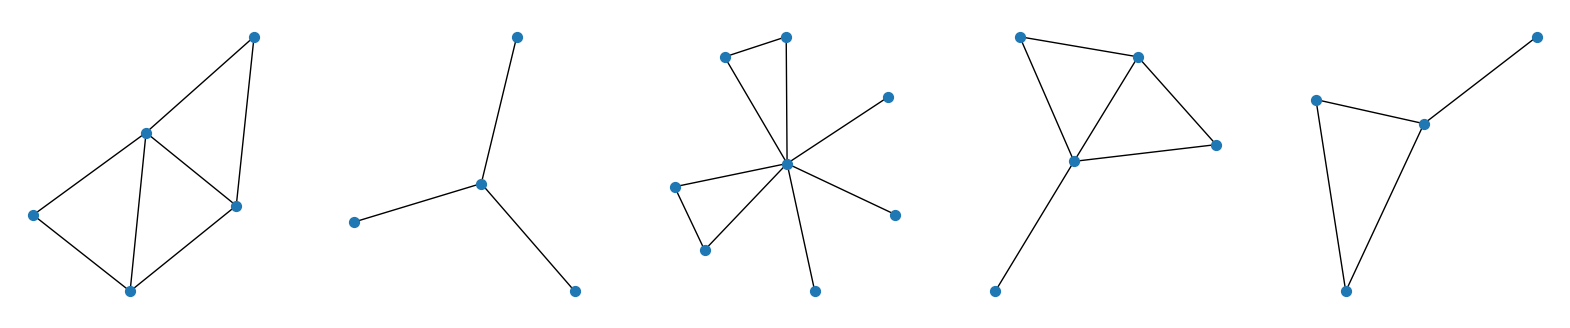

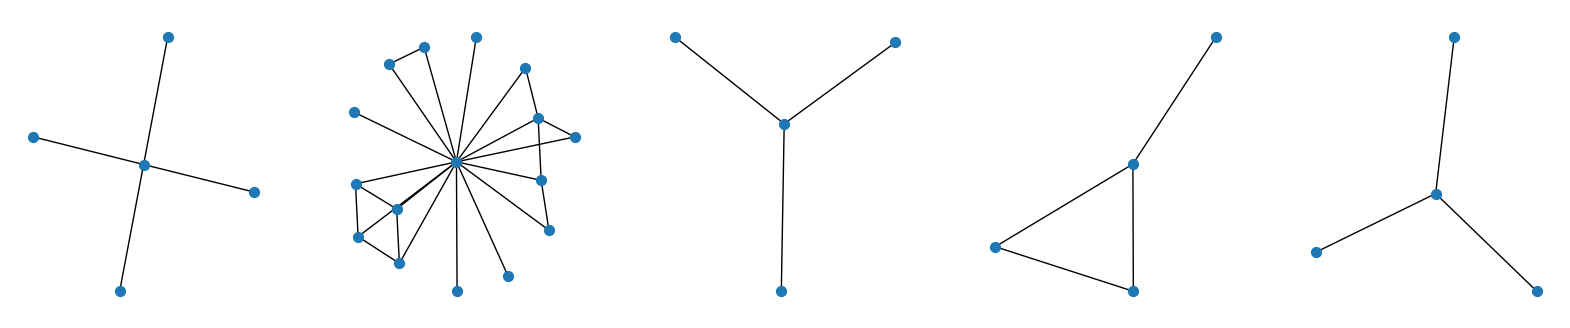

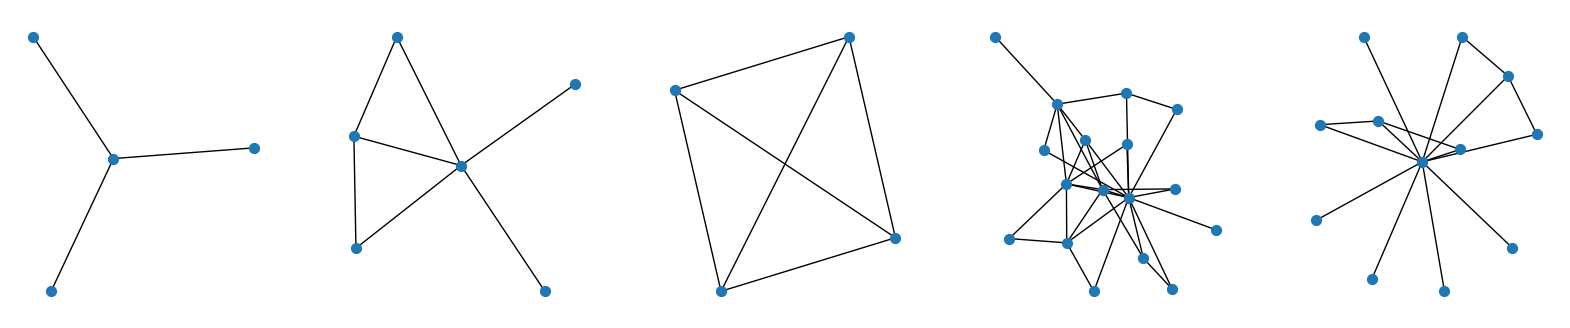

In [ ]:
ds = 'egosm'
node_size = 50
display_graphs_from_ckpt_nx(f'{ds}-bg', v=0, how_many=5, node_size=node_size)
display_graphs_from_ckpt_nx(f'{ds}-sm', v=0, how_many=5, node_size=node_size)
display_graphs_from_ckpt_nx(f'{ds}-mifh', v=0, how_many=5, node_size=node_size)

In [90]:
from src.data.datasets.graphgdp_datasets import Enzymes, Ego, EgoSmall, CommunitySmall
ds_train = CommunitySmall(split="train")

/home/dkm/.conda/envs/ifh-gen/lib/python3.11/site-packages/torch_geometric/io/fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([SparseGraph])` to allowlist this global.
  warnings.warn(f"{warn_msg} Please use "


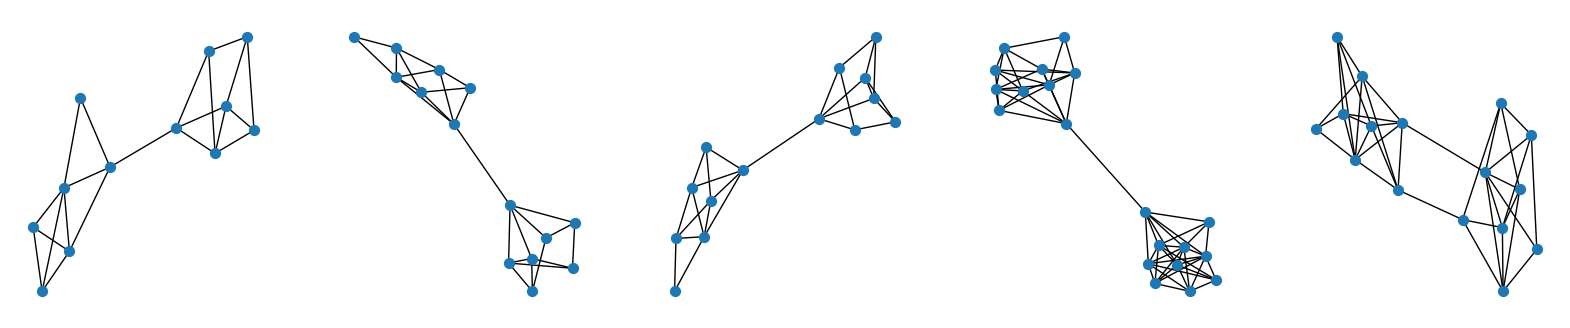

In [ ]:
import torch
torch.manual_seed(0)
node_size = 50
graphs_train = graph2nx(ds_train[torch.randint(0, len(ds_train), (5,))], to_undirected=True)
display_graphs(graphs_train, 'comm-train', node_size=node_size)

## Molecular datasets

In [178]:
from hydra import compose, initialize
from omegaconf import DictConfig, OmegaConf, open_dict
from hydra.core.hydra_config import HydraConfig
from src.configurator import RunContext

overrides = "+preset/ifh/qm9=1-4 seed=0 load_ckp=0 enable_log=false compile=false mode=eval +options=remap_cls"

# context initialization
with initialize(version_base=None, config_path="config"):
    cfg = compose(config_name="default", overrides=overrides.split(), return_hydra_config=True)

context: RunContext = RunContext.from_config(cfg)

2026-03-10 10:54:10,093 - context - INFO - Reading execution arguments...
2026-03-10 10:54:10,095 - context - INFO -     Configuring run "qm9-bg"
2026-03-10 10:54:10,096 - context - INFO -     Group name: qm9-bg
2026-03-10 10:54:10,097 - context - INFO -     Run mode: eval
2026-03-10 10:54:10,098 - context - INFO -     Debug mode: False
2026-03-10 10:54:10,098 - context - INFO -     Checkpoints enabled: True
2026-03-10 10:54:10,099 - context - INFO -     Wandb logging enabled: False
2026-03-10 10:54:10,100 - context - INFO -     Profiling: False
2026-03-10 10:54:10,101 - context - INFO -     Resuming run: 0
2026-03-10 10:54:10,101 - context - INFO -     Seed: 0
2026-03-10 10:54:10,102 - context - INFO - Execution arguments read with success
2026-03-10 10:54:10,103 - context - INFO - Setting seed to 0...
2026-03-10 10:54:10,107 - context - INFO - Seed set with success
2026-03-10 10:54:10,108 - context - INFO - Running checks on the context...
2026-03-10 10:54:10,109 - context - INFO - C

AlignLabelsAdapter: x_changed=True, e_changed=True
Reordering: ['F', 'N', 'C', 'O']
Reordering: ['TRIPLE', 'SINGLE', 'DOUBLE']
AlignLabelsAdapter: x_changed=True, e_changed=True
Keeping original ordering: ['F', 'N', 'C', 'O']
Keeping original ordering: ['TRIPLE', 'SINGLE', 'DOUBLE']
AlignLabelsAdapter: x_changed=True, e_changed=True
Keeping original ordering: ['F', 'N', 'C', 'O']
Keeping original ordering: ['TRIPLE', 'SINGLE', 'DOUBLE']


In [186]:
from rdkit import Chem
from rdkit.Chem import Draw
import cairosvg
from PIL import Image
import io

path = 'outputs/figures'

def display_molecules(mol_graphs, ds_model, how_many=5, node_size=50, save=True):
    # display mol grid with rdkit, mol_graphs are already rdkit Mol
    mols = mol_graphs[:how_many]
    svg_obj = Draw.MolsToGridImage(mols, molsPerRow=how_many, subImgSize=(300, 300), useSVG=True)
    # Extract SVG string
    svg = svg_obj.data if hasattr(svg_obj, "data") else svg_obj
    
    png_bytes = cairosvg.svg2png(bytestring=svg.encode('utf-8'), scale=2.0)
    img = Image.open(io.BytesIO(png_bytes)).convert("RGBA")
    fig = plt.figure(figsize=(4 * how_many, 4))
    plt.imshow(img)
    plt.axis('off')

    if save:
        #fig.savefig(f'{path}/{ds_model}.pdf', bbox_inches='tight')
        cairosvg.svg2pdf(bytestring=svg.encode("utf-8"), write_to=f'{path}/{ds_model}.pdf')

def display_graphs_from_ckpt_mol(decoder, ds_name, v=0, how_many=5, node_size=50):
    paths = get_graphs_path(ds_name, v)
    if isinstance(paths, list):
        paths = sorted(paths)
        path = paths[-1]
    else:
        path = paths
    graphs = get_graphs(path)
    nx_graphs = decoder(graphs)
    display_graphs(nx_graphs, ds_name, how_many, node_size)

In [180]:
paths = get_graphs_path('qm9-bg')
if isinstance(paths, list):
    paths = sorted(paths)
    path = paths[-1]
else:
    path = paths
graphs = get_graphs(path)

In [181]:
decoder = context.data_resources.decoder
mols = decoder(graphs)

In [182]:
from src.data.simple_transforms.molecular import mol2smiles

valid = []
for mol in mols:
    try:
        smiles = mol2smiles(mol)
        if smiles is not None:
            valid.append(smiles)
    except Exception as e:
        print(f'Error converting molecule to SMILES: {e}')
        
len(valid) / len(mols)

1.0

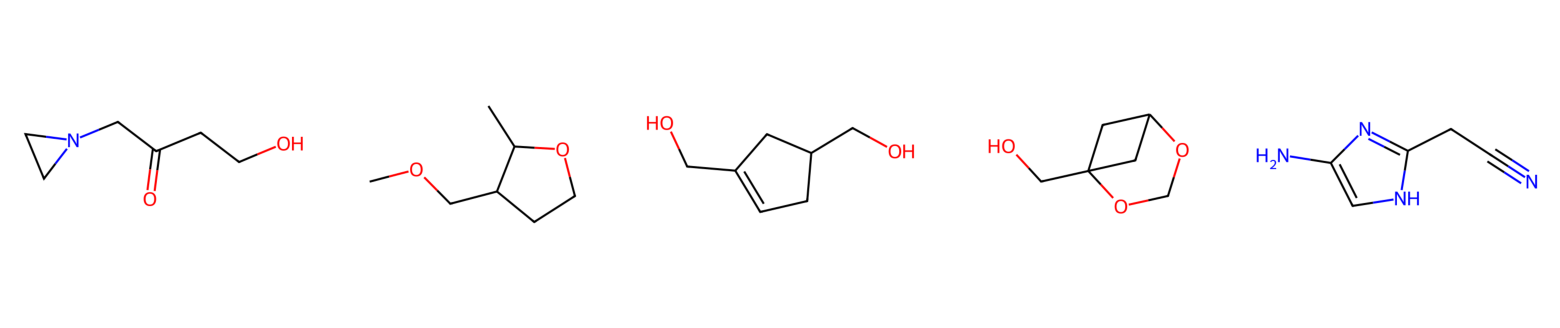

In [187]:
display_molecules(mols[5:], 'qm9-bg', how_many=5, node_size=50, save=True)

In [160]:
from src.data.datasets.zinc import ZincSmiles
ds_train = ZincSmiles(split="train")

In [188]:
from src.data.datasets.qm9_dig import QM9DigSmiles
ds_train = QM9DigSmiles(split="train")

In [189]:
from src.data.simple_transforms.molecular import smiles2mol
data_mols = smiles2mol(ds_train[:5][0])

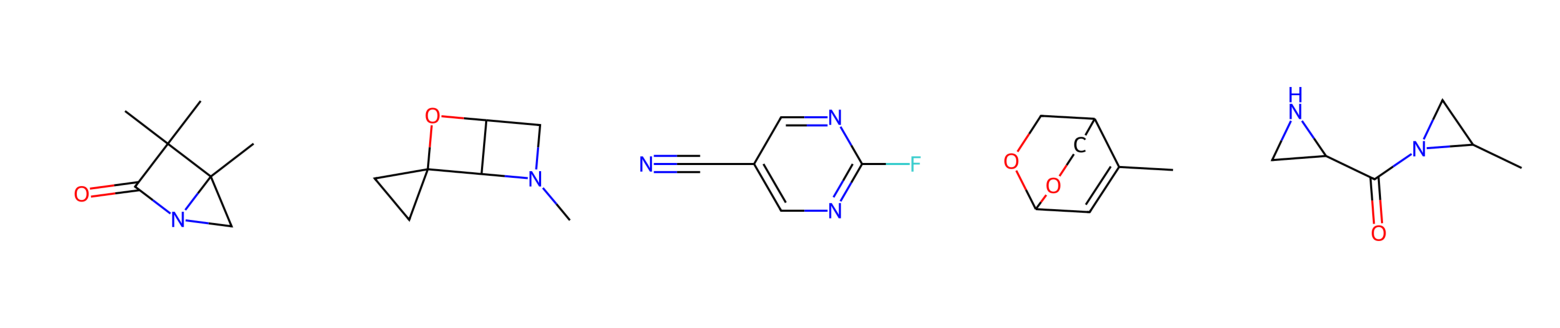

In [190]:
display_molecules(data_mols, 'qm9-train', how_many=5, node_size=50, save=True)